In [1]:
print("asdf")

asdf


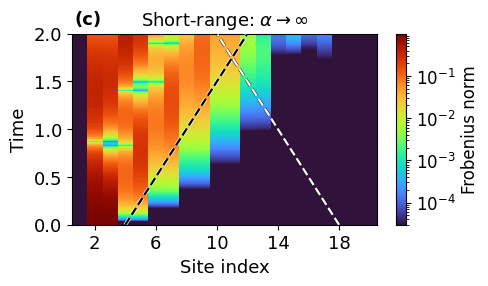

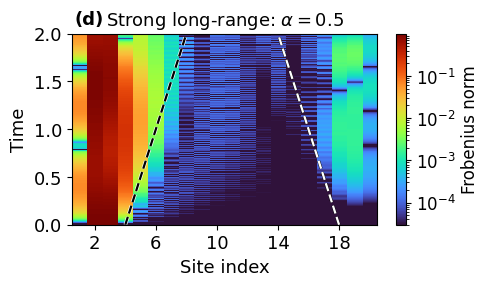

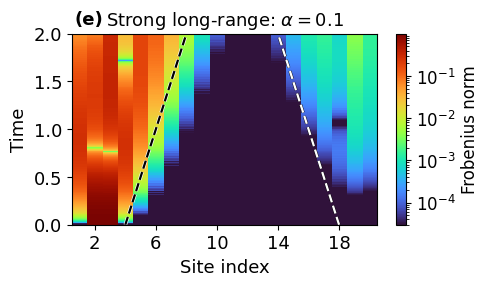

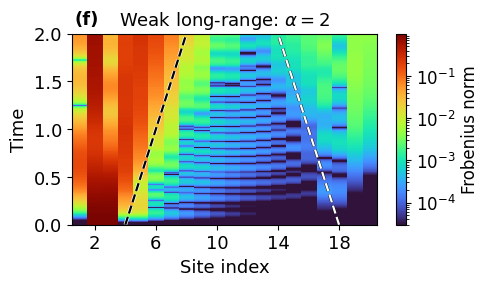

In [47]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
import matplotlib.patheffects as pe
import string

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([1000, 5, 1, 20]) #2 1,2,5,10,20, 30, 100, 1000
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 1
Jz = 1            # <-- set this to whatever you use in the simulation
x0_site = 3.5       # originating site index
use_site_centered_extent = True
n_sites=20
eps = 3e-5
os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
alphanum=0
for J in Jlong_values:
    alphanum+=1
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx5Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=eps, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict[J]

    # Choose velocity based on alpha regime
    v = None
    
    # -----------------------------
    # Velocity choice (copying your logic)
    # -----------------------------
    if J >= 100:
        v = 4 * Jz
    else:
        v = 2 * Jz

    # -----------------------------
    # Light-cone rays
    # -----------------------------
    if use_site_centered_extent:
        # x runs 0..Nsites, and "site i" centered at i-0.5
        x_min, x_max = 0.0, float(n_sites)
        extent = [x_min, x_max, t_min, t_max]
    else:
        # x runs 0..Nsites-1
        x_min, x_max = 0.0, float(n_sites - 1)
        extent = [x_min, x_max, t_min, t_max]

    # x0_site_right = 3.5  # site-centered origin (site 19 ~ 18.5 on imshow with -0.5 alignment)
    x0_site_left  = 17.5  # left-moving ray origin
    t_line_points = 400

    # -----------------------------
    # Panel label (optional)
    # -----------------------------
    # label = "(b)" if J == 1 else "(a)"
    label = f"({string.ascii_lowercase[alphanum+2-1]})"
    plt.text(
        0.01, 1.12, label,
        transform=plt.gca().transAxes,
        fontsize=13, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )


    t_line = np.linspace(t_min, t_max, t_line_points)
    x0_site_right=3.5
    # Right-moving ray from x0_site_right
    x_line_right = x0_site_right + v * t_line
    mask_right = (x_line_right >= x_min) & (x_line_right <= x_max)

    plt.plot(
        x_line_right[mask_right], t_line[mask_right],
        linestyle="--",
        color="black",
        linewidth=1.6,
        zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.6, foreground="white"),  # white outline
            pe.Normal()
        ]
    )

    # Left-moving ray from x0_site_left (white dashed)
    x_line_left = x0_site_left - v * t_line
    mask_left = (x_line_left >= x_min) & (x_line_left <= x_max)

    plt.plot(
        x_line_left[mask_left], t_line[mask_left],
        linestyle="--",
        color="white",
        linewidth=1.6,
        zorder=6,
        path_effects=[
            pe.Stroke(linewidth=2.2, foreground="black"),  # optional black outline so white stays visible
            pe.Normal()
        ]
    )

    cbar = plt.colorbar(im)
    cbar.set_label("Frobenius norm", fontsize=12)
    cbar.ax.tick_params(labelsize=12)
    plt.xlabel("Site index", fontsize=13)
    plt.ylabel("Time", fontsize=13)
    if J == 5:
        plt.title(fr"Strong long-range: $\alpha=0.5$", fontsize=13)
    if J == 1:
        plt.title(fr"Strong long-range: $\alpha=0.1$", fontsize=13)
    if J == 20:
        plt.title(fr"Weak long-range: $\alpha=2$", fontsize=13)
    elif J == 1000:
        plt.title(fr"Short-range: $\alpha\to\infty$", fontsize=13)
    else:
        alpha_label = f"{J/10:.1f}"


    # plt.title(fr"(2,19;3,19) $J_{{x}}={5}, J_z=1, \alpha={alpha_label}$", fontsize=12)



    # --- Custom X ticks (aligned to site centers) ---
    xticks = np.array(np.arange(2,20,4))   # or range(0, raw_data.shape[1], 5)
    plt.xticks(xticks - 0.5, [str(x) for x in xticks], fontsize=13)
    plt.yticks([0, 0.5, 1, 1.5, 2], fontsize=13)

    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N20Jx5alpha{J}.svg", dpi=600)
    plt.show()




# -----------------------------

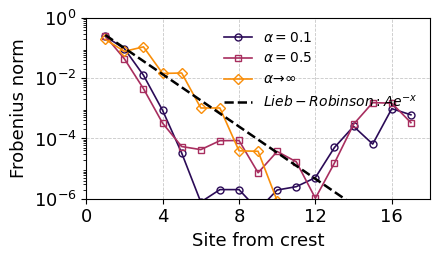

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.optimize import curve_fit

Jlong_values = np.array([1, 5, 1000])   # J=1000 used as "∞" label
time_for_profile = 1

plt.figure(figsize=(4.5, 2.7))

# Brighter inferno range
cmap = plt.cm.inferno
ncurves = len(Jlong_values)
colors = [cmap(0.15 + 0.60 * i / max(ncurves - 1, 1)) for i in range(ncurves)]
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h", "+", "1", ">"]

# store alpha->infty curve for fitting
sites_inf, prof_inf = None, None

for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx5Varya0{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)

    profile = raw_data[t_index, 3:]
    if J==1000:
        profile = raw_data[t_index, 4:]
    sites = np.arange(1, profile.size + 1)

    # keep only positive / above floor points for semilogy
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Save ONLY the alpha->infty curve for fitting
    if J == 1000:
        sites_inf = sites.copy()
        prof_inf = profile.copy()

    # labels
    label = r"$\alpha\!\to\!\infty$" if J == 1000 else fr"$\alpha={J/10:.1f}$"

    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Fit ONLY alpha->infty (pure exponential in x)
# log y = logA - a x
# -----------------------------
def log_model_exp(x, logA, a):
    return logA - a * x

if sites_inf is None or prof_inf is None or sites_inf.size < 3:
    print("Not enough points in alpha->infty curve to fit; skipping fit curve.")
else:
    n_fit = 6  # how many early sites you want to fit
    take = min(n_fit, sites_inf.size)

    x_fit = sites_inf[:take].astype(float)
    y_fit = prof_inf[:take].astype(float)

    # safety mask (log requires >0)
    mfit = y_fit > 1e-14
    x_fit, y_fit = x_fit[mfit], y_fit[mfit]

    if x_fit.size >= 3:
        popt, _ = curve_fit(
            log_model_exp, x_fit, np.log(y_fit),
            p0=(np.log(y_fit.max()), 0.2),
            maxfev=20000
        )
        logA_fit, a_fit = popt
        A_fit = np.exp(logA_fit)
        a_fit=1

        # draw fit only over the shown x-range (prevents xlim surprises)
        x_dense = np.linspace(1, 18, 400)
        y_dense = A_fit * np.exp(-a_fit * x_dense)

        plt.semilogy(
            x_dense, y_dense, "k--", linewidth=1.8,
            label=fr"$Lieb-Robinson: A e^{{-x}}$"
        )
    else:
        print("Too few valid (>1e-14) points in alpha->infty curve for fitting.")

# -----------------------------
# Formatting
# -----------------------------
plt.xticks(np.arange(0, 20, 4), fontsize=13)
plt.yticks([1e-6,1e-4,1e-2,1e-0] , fontsize=13)
plt.xlabel("Site from crest", fontsize=13)
plt.ylabel("Frobenius norm", fontsize=13)
# plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=10, loc="upper right", ncol=1, frameon=False)
plt.ylim(1e-6, 1)

# IMPORTANT: set limits LAST (after fit line)
plt.xlim(0, 18)

plt.tight_layout()
plt.savefig("plt/Profiles_N20Jx5Varyalpha2.svg", dpi=600)
plt.show()

In [10]:
np.arange(1e-6, 1e-0, 1e-4)

array([1.00000e-06, 1.01000e-04, 2.01000e-04, ..., 9.99701e-01,
       9.99801e-01, 9.99901e-01], shape=(10000,))

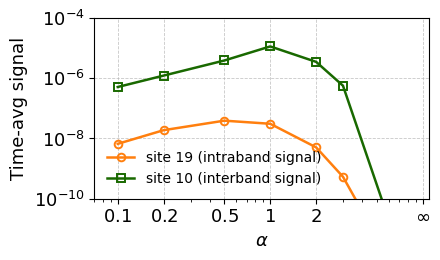

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import os

steps_per_unit = 100  # 0.01 time step

def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

def time_avg_vs_alpha(site_index, base_path="src",
                      Jlong_values=np.array([1,2,5,10,20,30, 100]),
                      t_min=0.0, t_max=0.05):
    alphas, avgs = [], []

    for J in Jlong_values:
        fp = os.path.join(base_path, f"B0LFIMb2N20Jx5Varya0{J}.txt")
        if not os.path.exists(fp):
            print(f"⚠️ Missing: {fp}")
            continue
        raw = load_mathematica_data(fp)
        time_axis = np.arange(raw.shape[0]) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        if not np.any(mask):
            continue
        avgs.append(np.mean(raw[mask, site_index]))
        alphas.append(J / 10)

    # add "alpha ~ 0" point (your manual convention)
    J0 = 0
    fp0 = os.path.join(base_path, f"B0LFIMb2N20Jx5Varya0{J0}.txt")
    if os.path.exists(fp0):
        raw0 = load_mathematica_data(fp0)
        time_axis0 = np.arange(raw0.shape[0]) / steps_per_unit
        mask0 = (time_axis0 >= t_min) & (time_axis0 <= t_max)
        if np.any(mask0):
            alphas.insert(0, 0.09)
            avgs.insert(0, np.mean(raw0[mask0, site_index]))

    alphas = np.array(alphas, dtype=float)
    avgs = np.array(avgs, dtype=float)

    # sort by alpha so lines connect properly
    order = np.argsort(alphas)
    return alphas[order], avgs[order]

# -----------------------------
# Superimposed plot
# -----------------------------
plt.figure(figsize=(4.5, 2.7))

t_min, t_max = 0.0, 0.05
base_path = "src"

# bright, high-contrast colors
c19 = "#ff7f0e"   # bright orange
c10 = "#196900"   # bright cyan

# site 19 (0-based index 18)
a19, y19 = time_avg_vs_alpha(site_index=18, base_path=base_path,
                             t_min=t_min, t_max=t_max)

# enforce alpha = infinity → numerical zero
y19[a19 >= 10] = 1e-14

plt.plot(
    a19, y19,
    "o-", linewidth=1.8, markersize=5.5,
    color=c19,
    markerfacecolor="none",
    markeredgewidth=1.4,
    label="site 19 (intraband signal)"
)

# site 10 (0-based index 9)
a10, y10 = time_avg_vs_alpha(site_index=9, base_path=base_path,
                             t_min=t_min, t_max=t_max)

# enforce alpha = infinity → numerical zero
y10[a10 >= 10] = 1e-14

plt.plot(
    a10, y10,
    "s-", linewidth=1.8, markersize=5.5,
    color=c10,
    markerfacecolor="none",
    markeredgewidth=1.4,
    label="site 10 (interband signal)"
)

# axes / styling
plt.xscale("log")
plt.yscale("log")
plt.xlim(0.07, 11)
plt.ylim(1e-10, 1e-4)

xticks = [0.1, 0.2, 0.5, 1, 2, 10]
xlabels = [r"$0.1$", r"$0.2$", r"$0.5$", r"$1$", r"$2$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=13)
plt.yticks([1e-10,1e-8,1e-6,1e-4] , fontsize=13)
plt.xlabel(r"$\alpha$", fontsize=13)
plt.ylabel(r"Time-avg signal", fontsize=13)
# plt.title(r"(2,19;3,19), $J_z{=}1$, $J_{\mathrm{x}}{=}5$, $N{=}20$", fontsize=13)

plt.legend(fontsize=10, loc="best", frameon=False)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()

os.makedirs("plt", exist_ok=True)
plt.savefig("plt/TimeAvg_intra_interbandSignal.svg", dpi=600)
plt.show()

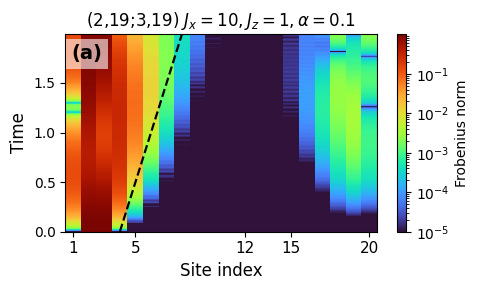

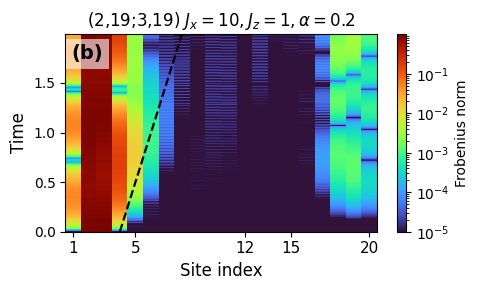

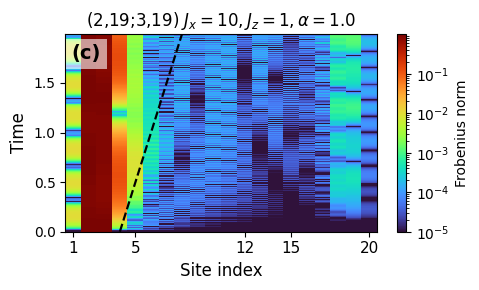

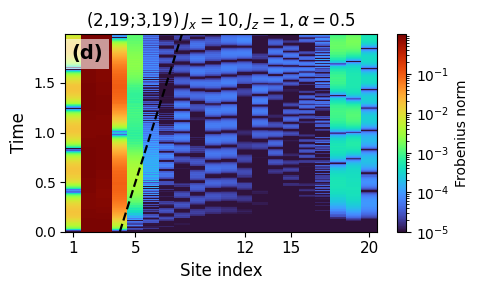

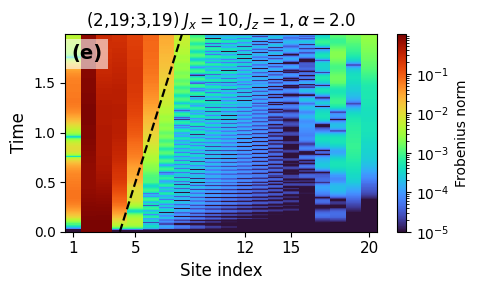

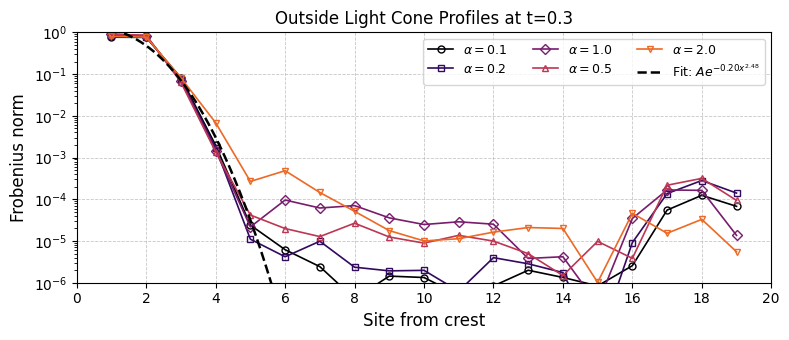

In [4]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([1,2, 10, 5,20]) #2
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 0.3
Jz = 1            # <-- set this to whatever you use in the simulation
x0_site = 3.5       # originating site index

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-5, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict[J]

    # Choose velocity based on alpha regime
    v = None
    
    if J == 1000:   # alpha -> infinity panel
        v = 4 * Jz
    else:
        v = 2 * Jz

    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    if v is not None:
        # time range on this panel
        t_line = np.linspace(t_min, t_max, 400)
        x_line = x0_site + v * t_line

        # keep only the part visible in the panel
        x_min, x_max = 0, raw_data.shape[1]
        mask = (x_line >= x_min) & (x_line <= x_max)
        plt.plot(x_line[mask], t_line[mask], "k--", linewidth=1.6, zorder=5)

    # # optional label near the start
    # plt.text(
    #     x0_site + 0.3, t_min + 0.05*(t_max - t_min),
    #     fr"$v={v}J_z$" if Jz == 1 else fr"$v={v}$",
    #     color="k", fontsize=10,
    #     bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    # )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    if J == 5:
        alpha_label = "0.5"
    elif J == 1000:
        alpha_label = r"\infty"
    else:
        alpha_label = f"{J/10:.1f}"

    plt.title(fr"(2,19;3,19) $J_{{x}}={10}, J_z=1, \alpha={alpha_label}$", fontsize=12)



    # --- Custom X ticks (aligned to site centers) ---
    xticks = np.array([1, 5, 12, 15, 20])   # or range(0, raw_data.shape[1], 5)
    plt.xticks(xticks - 0.5, [str(x) for x in xticks], fontsize=11)


    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N20Jx10alpha{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(8, 3.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 6) for i in range(0,6)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h", "+", "1", ">"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 1:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 5
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, 10, 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-6, 1)
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 2)) 
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="upper right", ncol=3)
plt.tight_layout()
plt.savefig("plt/Profiles_N20Jx10Varyalpha2.svg", dpi=600)
plt.show()
# -----------------------------

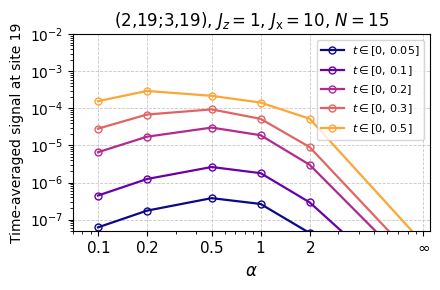

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import os

steps_per_unit = 100  # 0.01 time step

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Time-averaged signal vs α for multiple time windows
# -----------------------------
plt.figure(figsize=(4.5, 3))

Jlong_values = np.array([1,2,5,10,20,1000])
# Jlong_values = np.append(np.arange(1, 11), [20, 100])
base_path = "src"
site_index = 18  # site 13 in paper (0-based index)

# Define time windows: (t_min, t_max)
time_windows = [(0.0, 0.05),(0.0, 0.1), (0.0, 0.2), (0.0, 0.3), (0.0, 0.5)]
cmap = plt.cm.plasma
colors = [cmap(i / (len(time_windows))) for i in range(len(time_windows))]

for (t_min, t_max), c in zip(time_windows, colors):
    time_averages = []
    alphas = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J}.txt")
        if not os.path.exists(file_path):
            print(f"⚠️ Missing: {file_path}")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        if not np.any(mask):
            continue

        signal = raw_data[mask, site_index]
        avg_value = np.mean(signal)
        time_averages.append(avg_value)
        alphas.append(J / 10)

    # Add α = 0 case manually
    J0 = 0
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J0}.txt")
    if os.path.exists(file_path):
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        avg0 = np.mean(raw_data[mask, site_index])
        alphas.insert(0, 0.09)
        time_averages.insert(0, avg0)

    alphas = np.array(alphas)
    time_averages = np.array(time_averages)

    plt.plot(
        alphas, time_averages,
        'o-', linewidth=1.6, markersize=5,
        color=c, markerfacecolor='none', markeredgecolor=c,
        label=fr"$t \in [{t_min:.0f},\,{t_max}]$"
    )

# --- Axes scaling ---
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 11)
plt.ylim(5e-8, 1e-2)

# --- Custom X ticks ---
xticks = [0.1, 0.2, 0.5, 1, 2, 10]
xlabels = [r"$0.1$", r"$0.2$", r"$0.5$", r"$1$", r"$2$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels & styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Time-averaged signal at site 19", fontsize=10)
plt.title(r"(2,19;3,19), $J_z{=}1$, $J_{\mathrm{x}}{=}10$, $N{=}15$", fontsize=12)
plt.legend(fontsize=8, loc="best", frameon=True,ncol=1)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Jx10Alpha2.svg", dpi=600)
plt.show()


Fit for t in [0.0, 0.5]: alpha^1.102371


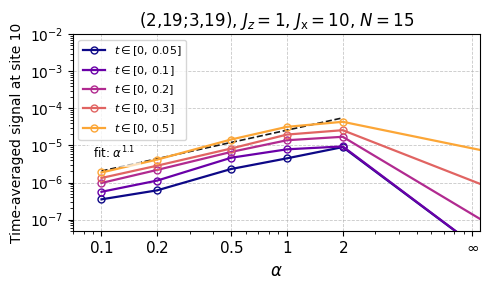

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import os

steps_per_unit = 100  # 0.01 time step

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Time-averaged signal vs α for multiple time windows
# -----------------------------
plt.figure(figsize=(5, 3))

Jlong_values = np.array([1,2,5,10,20,1000]) #
# Jlong_values = np.append(np.arange(1, 11), [20, 100])
base_path = "src"
site_index = 9  # site 13 in paper (0-based index)

# Define time windows: (t_min, t_max)
time_windows = [(0.0, 0.05),(0.0, 0.1), (0.0, 0.2), (0.0, 0.3),(0.0, 0.5)] #
cmap = plt.cm.plasma
colors = [cmap(i / (len(time_windows))) for i in range(len(time_windows))]

for (t_min, t_max), c in zip(time_windows, colors):
    time_averages = []
    alphas = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J}.txt")
        if not os.path.exists(file_path):
            print(f"⚠️ Missing: {file_path}")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        if not np.any(mask):
            continue

        signal = raw_data[mask, site_index]
        avg_value = np.mean(signal)
        time_averages.append(avg_value)
        alphas.append(J / 10)

    # Add α = 0 case manually
    J0 = 0
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx10Varya0{J0}.txt")
    if os.path.exists(file_path):
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        avg0 = np.mean(raw_data[mask, site_index])
        alphas.insert(0, 0.09)
        time_averages.insert(0, avg0)

    alphas = np.array(alphas)
    time_averages = np.array(time_averages)

    if t_max==0.5:
        # -----------------------------
        # Power-law fit on alpha in [0.1, 2] for THIS time window
        # -----------------------------
        alpha_lo, alpha_hi = 0.1, 2.0

        # Only use points in the fit range, exclude the "infty" point (alpha=100) automatically
        fit_mask = (alphas >= alpha_lo) & (alphas <= alpha_hi) & np.isfinite(time_averages) & (time_averages > 0)

        if np.count_nonzero(fit_mask) >= 2:
            x = alphas[fit_mask]
            y = time_averages[fit_mask]

            # Fit: log(y) = m log(x) + b  => y = A x^m, A = exp(b)
            m_fit, b_fit = np.polyfit(np.log(x), np.log(y), 1)
            A_fit = np.exp(b_fit)

            # Draw fitted line (black dashed) for this window
            x_line = np.logspace(np.log10(alpha_lo), np.log10(alpha_hi), 200)
            y_line = A_fit * x_line**m_fit
            plt.plot(x_line, y_line, "k--", linewidth=1.2, alpha=0.9)

            # Put the equation near the right side of the fit range
            # (stagger text vertically by time-window index to avoid overlap)
            idx = time_windows.index((t_min, t_max))
            y_text = 0.85 - 0.12 * idx  # adjust spacing if needed
            eqn = fr"fit: $\alpha^{{{m_fit:.1f}}}$"
            plt.text(
                0.05, y_text, eqn,
                transform=plt.gca().transAxes,
                fontsize=8.5,
                color="k",
                bbox=dict(facecolor="white", alpha=0.65, edgecolor="none")
            )

            print(f"Fit for t in [{t_min}, {t_max}]: alpha^{m_fit:.6f}")
        else:
            print(f"Not enough fit points in [{alpha_lo}, {alpha_hi}] for t in [{t_min}, {t_max}]")


    plt.plot(
        alphas, time_averages,
        'o-', linewidth=1.6, markersize=5,
        color=c, markerfacecolor='none', markeredgecolor=c,
        label=fr"$t \in [{t_min:.0f},\,{t_max}]$"
    )

# --- Axes scaling ---
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 11)
plt.ylim(5e-8, 1e-2)

# --- Custom X ticks ---
xticks = [0.1, 0.2, 0.5, 1, 2, 10]
xlabels = [r"$0.1$", r"$0.2$", r"$0.5$", r"$1$", r"$2$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels & styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Time-averaged signal at site 10", fontsize=10)
plt.title(r"(2,19;3,19), $J_z{=}1$, $J_{\mathrm{x}}{=}10$, $N{=}15$", fontsize=12)
plt.legend(fontsize=8, loc="best", frameon=True,ncol=1)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Jx10Alpha3.svg", dpi=600)
plt.show()


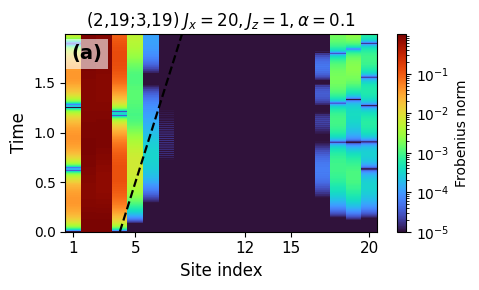

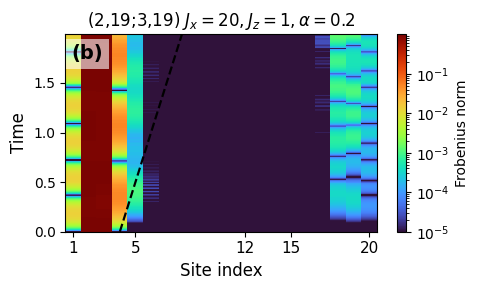

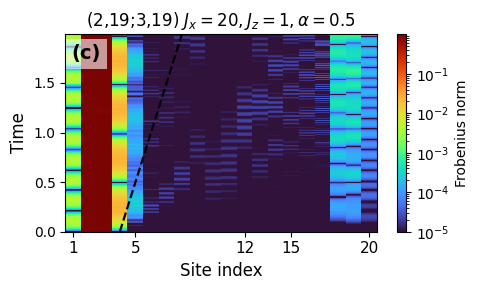

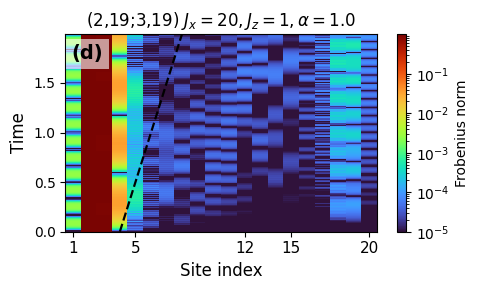

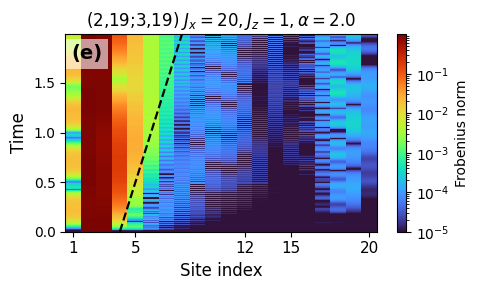

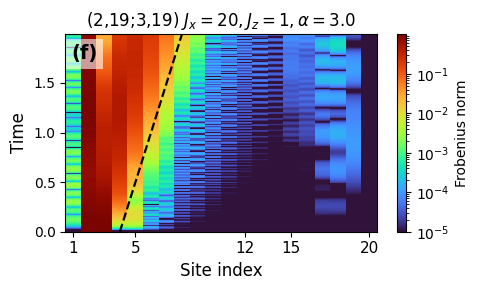

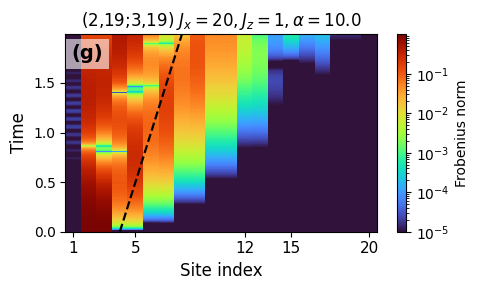

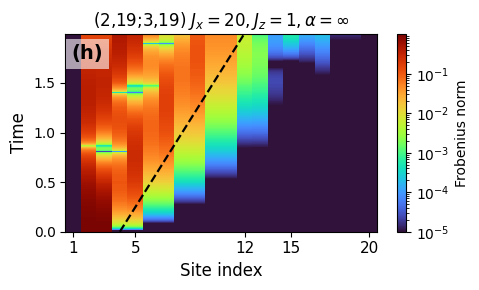

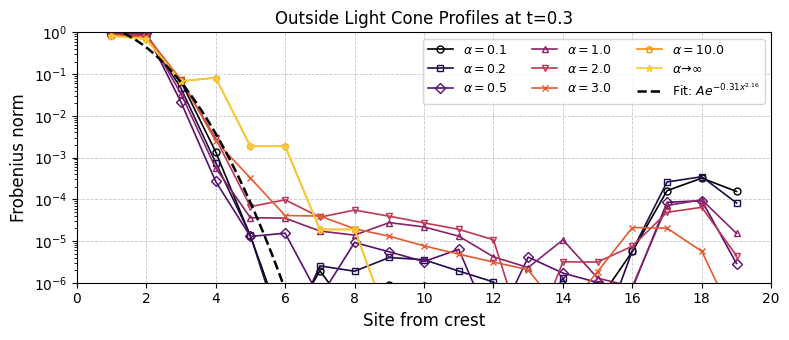

In [9]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Settings
# -----------------------------
Jlong_values = np.array([1,2,5,10, 20,30, 100, 1000]) #2
base_path = "src"
step_size = 0.01
steps_per_unit = 1 / step_size
time_for_profile = 0.3
Jz = 1            # <-- set this to whatever you use in the simulation
x0_site = 3.5       # originating site index

os.makedirs("plt", exist_ok=True)

# Precompute consistent color scale
# all_max = 0
# for J in Jlong_values:
#     data = load_mathematica_data(os.path.join(base_path, f"B0LFIMb2lcfara05VaryNWscaling{Jlong_values}.txt"))
#     all_max = max(all_max, np.nanmax(data))

# -----------------------------
# Generate three heatmaps
# -----------------------------
for J in Jlong_values:
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx20Varya0{J}.txt")
    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    time_axis = np.arange(n_steps) / steps_per_unit
    t_min, t_max = time_axis.min(), time_axis.max()

    plt.figure(figsize=(5, 3))
    im = plt.imshow(
        np.clip(raw_data, 1e-12, None),
        aspect="auto",
        origin="lower",
        cmap="turbo",
        norm=mcolors.LogNorm(vmin=1e-5, vmax=np.nanmax(raw_data)),
        interpolation="nearest",
        extent=[0, raw_data.shape[1], t_min, t_max],
        rasterized=True
    )

    label_dict = {j: f"({chr(96 + i)})" for i, j in enumerate(Jlong_values, start=1)}
    label = label_dict[J]

    # Choose velocity based on alpha regime
    v = None
    
    if J == 1000:   # alpha -> infinity panel
        v = 4 * Jz
    else:
        v = 2 * Jz

    plt.text(
        0.02, 0.95, label,
        transform=plt.gca().transAxes,
        fontsize=14, fontweight="bold",
        va="top", ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    if v is not None:
        # time range on this panel
        t_line = np.linspace(t_min, t_max, 400)
        x_line = x0_site + v * t_line

        # keep only the part visible in the panel
        x_min, x_max = 0, raw_data.shape[1]
        mask = (x_line >= x_min) & (x_line <= x_max)
        plt.plot(x_line[mask], t_line[mask], "k--", linewidth=1.6, zorder=5)

    # # optional label near the start
    # plt.text(
    #     x0_site + 0.3, t_min + 0.05*(t_max - t_min),
    #     fr"$v={v}J_z$" if Jz == 1 else fr"$v={v}$",
    #     color="k", fontsize=10,
    #     bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    # )

    plt.colorbar(im, label="Frobenius norm")
    plt.xlabel("Site index", fontsize=12)
    plt.ylabel("Time", fontsize=12)
    if J == 5:
        alpha_label = "0.5"
    elif J == 1000:
        alpha_label = r"\infty"
    else:
        alpha_label = f"{J/10:.1f}"

    plt.title(fr"(2,19;3,19) $J_{{x}}={20}, J_z=1, \alpha={alpha_label}$", fontsize=12)



    # --- Custom X ticks (aligned to site centers) ---
    xticks = np.array([1, 5, 12, 15, 20])   # or range(0, raw_data.shape[1], 5)
    plt.xticks(xticks - 0.5, [str(x) for x in xticks], fontsize=11)


    plt.tight_layout()
    plt.savefig(f"plt/Heatmap_N20Jx20alpha{J}.svg", dpi=600)
    plt.show()


# -----------------------------
# Profiles overlayed on one plot + global fit
# -----------------------------
plt.figure(figsize=(8, 3.5))

# Six shades that darken as α increases (use perceptually uniform colormap)
cmap = plt.cm.inferno
colors = [cmap(i / 8) for i in range(0,8)]

# Six distinct markers
markers = ["o", "s", "D", "^", "v", "x", "p", "*", "h", "+", "1", ">"]


all_x_fit, all_y_fit = [], []

# Jlong_values here encode α×10 (e.g., 0,5,10,...,1000 -> α=0.0,...,1.0)
for (J, c, m) in zip(Jlong_values, colors, markers):
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx20Varya0{J}.txt")
    if not os.path.exists(file_path):
        print(f"Warning: {file_path} not found, skipping.")
        continue

    raw_data = load_mathematica_data(file_path)
    n_steps = raw_data.shape[0]
    t_index = min(int(time_for_profile * steps_per_unit), n_steps - 1)
    profile = raw_data[t_index, 1:]
    sites = np.arange(1, profile.size + 1)
    mask = profile > 1e-14
    sites, profile = sites[mask], profile[mask]

    # Collect points for global fit
    n_fit = 5
    all_x_fit.extend(sites[:n_fit])
    all_y_fit.extend(profile[:n_fit])

    # Proper label (remove b since it's fixed)
    if J == 1000:
        label = r"$\alpha\!\to\!\infty$"
    else:
        label = fr"$\alpha={J/10:.1f}$"

    # Connected lines with open markers and darkening color
    plt.semilogy(
        sites, profile, '-', marker=m,
        markerfacecolor='none',
        markeredgecolor=c,
        color=c,
        markersize=5,
        linewidth=1.2,
        label=label
    )

# -----------------------------
# Global exponential fit
# -----------------------------
def log_model(x, logA, a, p):
    return logA - a * (x ** p)

x_fit_points = np.array(all_x_fit)
y_fit_points = np.array(all_y_fit)
mask = y_fit_points > 1e-14
x_fit_points, y_fit_points = x_fit_points[mask], y_fit_points[mask]

popt, _ = curve_fit(log_model, x_fit_points, np.log(y_fit_points),
                    p0=(np.log(y_fit_points.max()), 0.01, 2.0))
logA_fit, a_fit, p_fit = popt
A_fit = np.exp(logA_fit)

# Global fit line
x_dense = np.linspace(1, 10, 300)
y_dense = A_fit * np.exp(-a_fit * x_dense ** p_fit)
plt.semilogy(
    x_dense, y_dense, "k--", linewidth=1.8,
    label=fr"Fit: $A e^{{-{a_fit:.2f}x^{{{p_fit:.2f}}}}}$"
)

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(1e-6, 1)
plt.xlim(0, 20)
plt.xticks(np.arange(0, 21, 2)) 
plt.xlabel("Site from crest", fontsize=12)
plt.ylabel("Frobenius norm", fontsize=12)
plt.title(f"Outside Light Cone Profiles at t={time_for_profile}", fontsize=12)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.legend(fontsize=9, loc="upper right", ncol=3)
plt.tight_layout()
plt.savefig("plt/Profiles_N20Jx20Varyalpha2.svg", dpi=600)
plt.show()
# -----------------------------

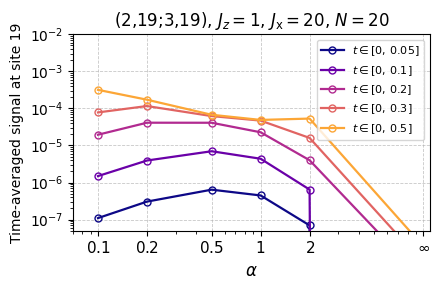

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import os

steps_per_unit = 100  # 0.01 time step

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Time-averaged signal vs α for multiple time windows
# -----------------------------
plt.figure(figsize=(4.5, 3))

Jlong_values = np.array([1,2,5,10,20,1000])
# Jlong_values = np.append(np.arange(1, 11), [20, 100])
base_path = "src"
site_index = 18  # site 13 in paper (0-based index)

# Define time windows: (t_min, t_max)
time_windows = [(0.0, 0.05),(0.0, 0.1), (0.0, 0.2), (0.0, 0.3), (0.0, 0.5)]
cmap = plt.cm.plasma
colors = [cmap(i / (len(time_windows))) for i in range(len(time_windows))]

for (t_min, t_max), c in zip(time_windows, colors):
    time_averages = []
    alphas = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"B0LFIMb2N20Jx20Varya0{J}.txt")
        if not os.path.exists(file_path):
            print(f"⚠️ Missing: {file_path}")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        if not np.any(mask):
            continue

        signal = raw_data[mask, site_index]
        avg_value = np.mean(signal)
        time_averages.append(avg_value)
        alphas.append(J / 10)

    # Add α = 0 case manually
    J0 = 0
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx20Varya0{J0}.txt")
    if os.path.exists(file_path):
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        avg0 = np.mean(raw_data[mask, site_index])
        alphas.insert(0, 0.09)
        time_averages.insert(0, avg0)

    alphas = np.array(alphas)
    time_averages = np.array(time_averages)

    plt.plot(
        alphas, time_averages,
        'o-', linewidth=1.6, markersize=5,
        color=c, markerfacecolor='none', markeredgecolor=c,
        label=fr"$t \in [{t_min:.0f},\,{t_max}]$"
    )

# --- Axes scaling ---
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 11)
plt.ylim(5e-8, 1e-2)

# --- Custom X ticks ---
xticks = [0.1, 0.2, 0.5, 1, 2, 10]
xlabels = [r"$0.1$", r"$0.2$", r"$0.5$", r"$1$", r"$2$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels & styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Time-averaged signal at site 19", fontsize=10)
plt.title(r"(2,19;3,19), $J_z{=}1$, $J_{\mathrm{x}}{=}20$, $N{=}20$", fontsize=12)
plt.legend(fontsize=8, loc="best", frameon=True,ncol=1)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Jx20Alpha2.svg", dpi=600)
plt.show()


Fit for t in [0.0, 0.5]: alpha^1.074103


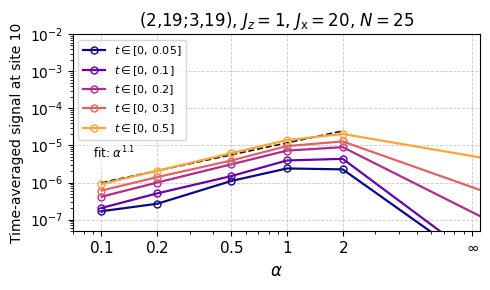

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import os

steps_per_unit = 100  # 0.01 time step

# -----------------------------
# Load Mathematica-style text files
# -----------------------------
def load_mathematica_data(filename):
    data = []
    with open(filename, "r") as f:
        for line in f:
            line = line.replace("*^", "e").strip().lstrip("{").rstrip("}")
            if not line:
                continue
            entries = line.split(",")
            row = []
            for e in entries:
                e = e.strip()
                if "+ 0." in e:
                    e = e.split("+")[0].strip()
                if "*I" in e:
                    continue
                try:
                    row.append(float(e))
                except ValueError:
                    pass
            if row:
                data.append(row)
    return np.array(data)

# -----------------------------
# Time-averaged signal vs α for multiple time windows
# -----------------------------
plt.figure(figsize=(5, 3))

Jlong_values = np.array([1,2,5,10,20,1000]) #
# Jlong_values = np.append(np.arange(1, 11), [20, 100])
base_path = "src"
site_index = 9  # site 13 in paper (0-based index)

# Define time windows: (t_min, t_max)
time_windows = [(0.0, 0.05),(0.0, 0.1), (0.0, 0.2), (0.0, 0.3),(0.0, 0.5)] #
cmap = plt.cm.plasma
colors = [cmap(i / (len(time_windows))) for i in range(len(time_windows))]

for (t_min, t_max), c in zip(time_windows, colors):
    time_averages = []
    alphas = []

    for J in Jlong_values:
        file_path = os.path.join(base_path, f"B0LFIMb2N20Jx20Varya0{J}.txt")
        if not os.path.exists(file_path):
            print(f"⚠️ Missing: {file_path}")
            continue

        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        if not np.any(mask):
            continue

        signal = raw_data[mask, site_index]
        avg_value = np.mean(signal)
        time_averages.append(avg_value)
        alphas.append(J / 10)

    # Add α = 0 case manually
    J0 = 0
    file_path = os.path.join(base_path, f"B0LFIMb2N20Jx20Varya0{J0}.txt")
    if os.path.exists(file_path):
        raw_data = load_mathematica_data(file_path)
        n_steps = raw_data.shape[0]
        time_axis = np.arange(n_steps) / steps_per_unit
        mask = (time_axis >= t_min) & (time_axis <= t_max)
        avg0 = np.mean(raw_data[mask, site_index])
        alphas.insert(0, 0.09)
        time_averages.insert(0, avg0)

    alphas = np.array(alphas)
    time_averages = np.array(time_averages)

    if t_max==0.5:
        # -----------------------------
        # Power-law fit on alpha in [0.1, 2] for THIS time window
        # -----------------------------
        alpha_lo, alpha_hi = 0.1, 2.0

        # Only use points in the fit range, exclude the "infty" point (alpha=100) automatically
        fit_mask = (alphas >= alpha_lo) & (alphas <= alpha_hi) & np.isfinite(time_averages) & (time_averages > 0)

        if np.count_nonzero(fit_mask) >= 2:
            x = alphas[fit_mask]
            y = time_averages[fit_mask]

            # Fit: log(y) = m log(x) + b  => y = A x^m, A = exp(b)
            m_fit, b_fit = np.polyfit(np.log(x), np.log(y), 1)
            A_fit = np.exp(b_fit)

            # Draw fitted line (black dashed) for this window
            x_line = np.logspace(np.log10(alpha_lo), np.log10(alpha_hi), 200)
            y_line = A_fit * x_line**m_fit
            plt.plot(x_line, y_line, "k--", linewidth=1.2, alpha=0.9)

            # Put the equation near the right side of the fit range
            # (stagger text vertically by time-window index to avoid overlap)
            idx = time_windows.index((t_min, t_max))
            y_text = 0.85 - 0.12 * idx  # adjust spacing if needed
            eqn = fr"fit: $\alpha^{{{m_fit:.1f}}}$"
            plt.text(
                0.05, y_text, eqn,
                transform=plt.gca().transAxes,
                fontsize=8.5,
                color="k",
                bbox=dict(facecolor="white", alpha=0.65, edgecolor="none")
            )

            print(f"Fit for t in [{t_min}, {t_max}]: alpha^{m_fit:.6f}")
        else:
            print(f"Not enough fit points in [{alpha_lo}, {alpha_hi}] for t in [{t_min}, {t_max}]")


    plt.plot(
        alphas, time_averages,
        'o-', linewidth=1.6, markersize=5,
        color=c, markerfacecolor='none', markeredgecolor=c,
        label=fr"$t \in [{t_min:.0f},\,{t_max}]$"
    )

# --- Axes scaling ---
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.07, 11)
plt.ylim(5e-8, 1e-2)

# --- Custom X ticks ---
xticks = [0.1, 0.2, 0.5, 1, 2, 10]
xlabels = [r"$0.1$", r"$0.2$", r"$0.5$", r"$1$", r"$2$", r"$\infty$"]
plt.xticks(xticks, xlabels, fontsize=11)

# --- Labels & styling ---
plt.xlabel(r"$\alpha$", fontsize=12)
plt.ylabel(r"Time-averaged signal at site 10", fontsize=10)
plt.title(r"(2,19;3,19), $J_z{=}1$, $J_{\mathrm{x}}{=}20$, $N{=}25$", fontsize=12)
plt.legend(fontsize=8, loc="best", frameon=True,ncol=1)
plt.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.savefig("plt/TimeAvg_vs_Jx20Alpha3.svg", dpi=600)
plt.show()
